<a href="https://colab.research.google.com/github/alwjr-hccs/ITAI_ML_FirstRepo_AWilliams/blob/main/AI_Assisted_College_Student_Email_Routing_Simulation_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# AI-Assisted College Student Email Routing
## Active Simulation / Proof-of-Concept Prototype

**Student:** Andrew Williams  
**Project:** Midterm AI Project Blueprint  
**Chosen idea:** College office — route student emails to the correct department.

### Purpose
This notebook simulates an AI-assisted routing system for incoming college student emails. The AI does **not** resolve the student's problem. It predicts the most appropriate destination department, displays a confidence score and explanation, and sends uncertain or incomplete cases to a **Student Services Triage Specialist** for human review.

### Departments in this simulation
- Admissions
- Financial Aid
- Registrar
- Bursar / Student Accounts
- Academic Advising
- IT Help Desk
- Career Services
- Student Services / Human Review

> **Important:** All sample messages are fictional. No private student records are used.


In [1]:

# Run this cell first.
# The prototype uses only common Python/Jupyter packages.

import re
import math
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, clear_output

try:
    import ipywidgets as widgets
    WIDGETS_AVAILABLE = True
except ImportError:
    WIDGETS_AVAILABLE = False

print("Simulation ready.")
print("Interactive widgets available:", WIDGETS_AVAILABLE)


Simulation ready.
Interactive widgets available: True



## 1. Business Decision and Workflow

**Decision supported:** Which college department should receive a newly received student email?

**AI output:** A suggested department, confidence score, and matched reasons/keywords.

**Human authority:** The AI recommendation is advisory. A Student Services Triage Specialist can accept, change, or override the route. Low-confidence, ambiguous, or missing-information cases are automatically escalated for human review.

### Redesigned workflow
1. Student email arrives.
2. Ordinary software checks that usable subject/body text exists.
3. AI analyzes the text and ranks departments.
4. A routing rule checks confidence and ambiguity.
5. High-confidence cases are proposed for the predicted team; uncertain cases go to a triage specialist.
6. A human can approve, reroute, or escalate.
7. The accepted destination and correction are logged for future evaluation.


In [13]:

# Department vocabulary for a transparent proof-of-concept classifier.
# This is a simulation of an AI classification task, not a trained production model.

DEPARTMENT_KEYWORDS = {
    "Admissions": {
        "apply": 2, "application": 3, "admission": 3, "admissions": 3,
        "transcript for admission": 3, "accepted": 2, "freshman": 2,
        "transfer student": 3, "enroll": 1
    },
    "Financial Aid": {
        "financial aid": 5, "fafsa": 5, "grant": 3, "scholarship": 3,
        "loan": 3, "aid package": 4, "pell": 4, "verification": 2
    },
    "Registrar": {
        "transcript": 4, "registration": 3, "register": 3, "drop class": 4,
        "add class": 4, "graduation": 3, "degree audit": 3, "records": 2,
        "enrollment verification": 4
    },
    "Bursar / Student Accounts": {
        "tuition": 4, "bill": 3, "billing": 3, "payment": 3, "balance": 3,
        "refund": 3, "student account": 4, "fee": 2, "payment plan": 4
    },
    "Academic Advising": {
        "advisor": 4, "advising": 4, "major": 3, "degree plan": 4,
        "which class": 3, "course selection": 4, "prerequisite": 3,
        "academic plan": 4
    },
    "IT Help Desk": {
        "password": 4, "login": 4, "log in": 4, "wifi": 4, "email account": 3,
        "canvas": 4, "blackboard": 4, "computer": 2, "technical": 2,
        "multi-factor": 4, "mfa": 4
    },
    "Career Services": {
        "resume": 4, "internship": 4, "career": 4, "job fair": 4,
        "interview practice": 4, "employer": 2, "job search": 4
    }
}

def normalize_text(text):
    text = (text or "").lower().strip()
    text = re.sub(r"\s+", " ", text)
    return text

def route_email(subject, body, confidence_threshold=0.62, ambiguity_margin=0.12):
    text = normalize_text(f"{subject} {body}")

    if len(text.replace(" ", "")) < 8:
        return {
            "suggested_department": "Student Services / Human Review",
            "confidence": 0.0,
            "status": "MISSING / UNUSABLE INFORMATION",
            "reason": "The message does not contain enough usable text to route safely.",
            "scores": {},
            "matched_terms": {}
        }

    raw_scores = {}
    matched = {}

    for dept, terms in DEPARTMENT_KEYWORDS.items():
        score = 0
        hits = []
        for term, weight in terms.items():
            if term in text:
                score += weight
                hits.append(term)
        raw_scores[dept] = score
        matched[dept] = hits

    ranked = sorted(raw_scores.items(), key=lambda x: x[1], reverse=True)
    best_dept, best_score = ranked[0]
    second_score = ranked[1][1] if len(ranked) > 1 else 0
    total = sum(raw_scores.values())

    if best_score == 0:
        return {
            "suggested_department": "Student Services / Human Review",
            "confidence": 0.20,
            "status": "UNCERTAIN — HUMAN REVIEW REQUIRED",
            "reason": "No reliable department-specific indicators were found.",
            "scores": raw_scores,
            "matched_terms": matched
        }

    # Transparent confidence approximation for the classroom prototype.
    dominance = best_score / max(total, 1)
    evidence = 1 - math.exp(-best_score / 4)
    confidence = min(0.99, 0.55 * dominance + 0.45 * evidence)
    second_conf = second_score / max(total, 1)
    margin = dominance - second_conf

    if confidence < confidence_threshold or margin < ambiguity_margin:
        status = "UNCERTAIN — HUMAN REVIEW REQUIRED"
        suggested = best_dept
        reason = (
            f"Best match is {best_dept}, but confidence/ambiguity rules require "
            "a Student Services Triage Specialist to review it."
        )
    else:
        status = "AI ROUTE SUGGESTION — HUMAN CAN OVERRIDE"
        suggested = best_dept
        reason = f"Strongest textual evidence points to {best_dept}."

    return {
        "suggested_department": suggested,
        "confidence": round(confidence, 3),
        "status": status,
        "reason": reason,
        "scores": raw_scores,
        "matched_terms": matched
    }


## 2. Test the AI on One Email

In [14]:

example = route_email(
    subject="Question about my FAFSA",
    body="My FAFSA was submitted but I do not see my financial aid package. Can someone help?"
)

display(pd.DataFrame([{
    "Suggested department": example["suggested_department"],
    "Confidence": example["confidence"],
    "Status": example["status"],
    "Reason": example["reason"]
}]))


,Suggested department,Confidence,Status,Reason
0,Financial Aid,0.986,AI ROUTE SUGGESTION — HUMAN CAN OVERRIDE,Strongest textual evidence points to Financial...



## 3. Interactive Routing Desk

Run the next cell. Type a fictional student email, click **Analyze & Route**, and act as the human reviewer.

- **Approve AI Route** accepts the suggestion.
- **Override Route** lets the reviewer select a different department.
- **Escalate** sends the case to Student Services / Human Review.
- Every final human action is recorded in a simulation log.


In [15]:

routing_log = []

if not WIDGETS_AVAILABLE:
    print("ipywidgets is not installed. Use route_email(subject, body) directly.")
else:
    subject_box = widgets.Text(
        description="Subject:",
        placeholder="Example: Problem with my tuition bill",
        layout=widgets.Layout(width="95%")
    )
    body_box = widgets.Textarea(
        description="Email:",
        placeholder="Type a fictional student email here...",
        layout=widgets.Layout(width="95%", height="120px")
    )
    analyze_btn = widgets.Button(description="Analyze & Route", button_style="primary")
    approve_btn = widgets.Button(description="Approve AI Route", button_style="success", disabled=True)
    escalate_btn = widgets.Button(description="Escalate", button_style="warning", disabled=True)
    override_dropdown = widgets.Dropdown(
        options=list(DEPARTMENT_KEYWORDS.keys()) + ["Student Services / Human Review"],
        description="Override:",
        disabled=True,
        layout=widgets.Layout(width="65%")
    )
    override_btn = widgets.Button(description="Override Route", disabled=True)
    output = widgets.Output()
    current = {"result": None}

    def show_result(result):
        with output:
            clear_output()
            display(Markdown(f"### AI Recommendation: **{result['suggested_department']}**"))
            display(Markdown(
                f"**Confidence:** {result['confidence']:.1%}  \\n"
                f"**Status:** {result['status']}  \\n"
                f"**Explanation:** {result['reason']}"
            ))
            rows = []
            for dept, score in sorted(result["scores"].items(), key=lambda x: x[1], reverse=True):
                if score > 0:
                    rows.append({
                        "Department": dept,
                        "Evidence score": score,
                        "Matched terms": ", ".join(result["matched_terms"][dept])
                    })
            if rows:
                display(pd.DataFrame(rows))

    def analyze(_):
        result = route_email(subject_box.value, body_box.value)
        current["result"] = result
        show_result(result)
        approve_btn.disabled = False
        escalate_btn.disabled = False
        override_dropdown.disabled = False
        override_btn.disabled = False

    def log_action(action, final_department):
        result = current["result"]
        routing_log.append({
            "Subject": subject_box.value,
            "Email": body_box.value,
            "AI suggestion": result["suggested_department"],
            "Confidence": result["confidence"],
            "AI status": result["status"],
            "Reviewer action": action,
            "Final department": final_department
        })
        with output:
            display(Markdown(
                f"**Reviewer decision recorded:** {action} → **{final_department}**"
            ))

    def approve(_):
        if current["result"]:
            log_action("Approved", current["result"]["suggested_department"])

    def escalate(_):
        if current["result"]:
            log_action("Escalated", "Student Services / Human Review")

    def override(_):
        if current["result"]:
            log_action("Overridden", override_dropdown.value)

    analyze_btn.on_click(analyze)
    approve_btn.on_click(approve)
    escalate_btn.on_click(escalate)
    override_btn.on_click(override)

    display(widgets.VBox([
        subject_box, body_box, analyze_btn, output,
        widgets.HBox([approve_btn, escalate_btn]),
        widgets.HBox([override_dropdown, override_btn])
    ]))


## 4. Fictional Test Cases

In [16]:

test_cases = pd.DataFrame([
    {
        "case": 1,
        "subject": "FAFSA verification",
        "body": "My FAFSA says I was selected for verification. What documents do I need?",
        "expected": "Financial Aid",
        "type": "normal"
    },
    {
        "case": 2,
        "subject": "Need official transcript",
        "body": "How can I order an official transcript for my employer?",
        "expected": "Registrar",
        "type": "normal"
    },
    {
        "case": 3,
        "subject": "Cannot log in to Canvas",
        "body": "My password works elsewhere but I cannot log in to Canvas.",
        "expected": "IT Help Desk",
        "type": "normal"
    },
    {
        "case": 4,
        "subject": "Tuition payment plan",
        "body": "I need to set up a payment plan for my tuition balance.",
        "expected": "Bursar / Student Accounts",
        "type": "normal"
    },
    {
        "case": 5,
        "subject": "Choosing classes for my major",
        "body": "I changed my major and need an advisor to help with course selection.",
        "expected": "Academic Advising",
        "type": "normal"
    },
    {
        "case": 6,
        "subject": "Internship and resume",
        "body": "Can someone review my resume before I apply for an internship?",
        "expected": "Career Services",
        "type": "normal"
    },
    {
        "case": 7,
        "subject": "Transfer application",
        "body": "I am a transfer student and have a question about my admissions application.",
        "expected": "Admissions",
        "type": "normal"
    },
    {
        "case": 8,
        "subject": "Refund and financial aid",
        "body": "My financial aid posted but I am waiting for a refund from my student account.",
        "expected": "Student Services / Human Review",
        "type": "difficult / ambiguous"
    },
    {
        "case": 9,
        "subject": "",
        "body": "Help",
        "expected": "Student Services / Human Review",
        "type": "missing information"
    },
    {
        "case": 10,
        "subject": "I need help",
        "body": "I am not sure who I need to talk to about a problem at school.",
        "expected": "Student Services / Human Review",
        "type": "uncertain"
    }
])

test_cases


,case,subject,body,expected,type
0,1,FAFSA verification,My FAFSA says I was selected for verification....,Financial Aid,normal
1,2,Need official transcript,How can I order an official transcript for my ...,Registrar,normal
2,3,Cannot log in to Canvas,My password works elsewhere but I cannot log i...,IT Help Desk,normal
3,4,Tuition payment plan,I need to set up a payment plan for my tuition...,Bursar / Student Accounts,normal
4,5,Choosing classes for my major,I changed my major and need an advisor to help...,Academic Advising,normal
5,6,Internship and resume,Can someone review my resume before I apply fo...,Career Services,normal
6,7,Transfer application,I am a transfer student and have a question ab...,Admissions,normal
7,8,Refund and financial aid,My financial aid posted but I am waiting for a...,Student Services / Human Review,difficult / ambiguous
8,9,,Help,Student Services / Human Review,missing information
9,10,I need help,I am not sure who I need to talk to about a pr...,Student Services / Human Review,uncertain


## 5. Batch Simulation and Evaluation

In [17]:

results = []

for _, row in test_cases.iterrows():
    r = route_email(row["subject"], row["body"])

    # For evaluation, any AI case requiring human review is treated as Human Review.
    evaluated_route = (
        "Student Services / Human Review"
        if "HUMAN REVIEW" in r["status"] or "MISSING" in r["status"]
        else r["suggested_department"]
    )

    results.append({
        "Case": row["case"],
        "Type": row["type"],
        "Expected": row["expected"],
        "AI suggestion": r["suggested_department"],
        "Workflow route": evaluated_route,
        "Confidence": r["confidence"],
        "Correct": evaluated_route == row["expected"]
    })

results_df = pd.DataFrame(results)
display(results_df)

accuracy = results_df["Correct"].mean()
review_rate = (results_df["Workflow route"] == "Student Services / Human Review").mean()

print(f"Routing accuracy on fictional sample cases: {accuracy:.1%}")
print(f"Human-review rate: {review_rate:.1%}")
print("These are prototype simulation results, not real-world performance claims.")


,Case,Type,Expected,AI suggestion,Workflow route,Confidence,Correct
0,1,normal,Financial Aid,Financial Aid,Financial Aid,0.922,True
1,2,normal,Registrar,Registrar,Registrar,0.651,True
2,3,normal,IT Help Desk,IT Help Desk,IT Help Desk,0.978,True
3,4,normal,Bursar / Student Accounts,Bursar / Student Accounts,Bursar / Student Accounts,0.986,True
4,5,normal,Academic Advising,Academic Advising,Academic Advising,0.971,True
5,6,normal,Career Services,Career Services,Career Services,0.829,True
6,7,normal,Admissions,Admissions,Admissions,0.978,True
7,8,difficult / ambiguous,Student Services / Human Review,Bursar / Student Accounts,Bursar / Student Accounts,0.693,False
8,9,missing information,Student Services / Human Review,Student Services / Human Review,Student Services / Human Review,0.000,True
9,10,uncertain,Student Services / Human Review,Student Services / Human Review,Student Services / Human Review,0.200,True


Routing accuracy on fictional sample cases: 90.0%
Human-review rate: 20.0%
These are prototype simulation results, not real-world performance claims.


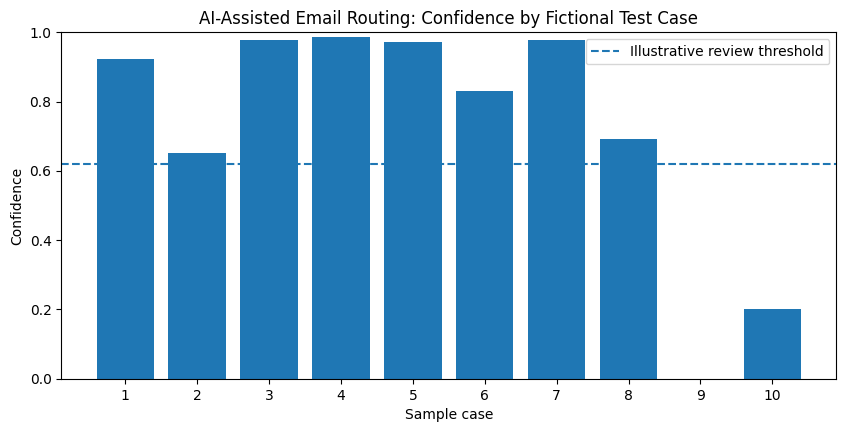

In [7]:

# Visualize confidence by sample case.
plt.figure(figsize=(10, 4.5))
plt.bar(results_df["Case"].astype(str), results_df["Confidence"])
plt.axhline(0.62, linestyle="--", linewidth=1.5, label="Illustrative review threshold")
plt.ylim(0, 1)
plt.xlabel("Sample case")
plt.ylabel("Confidence")
plt.title("AI-Assisted Email Routing: Confidence by Fictional Test Case")
plt.legend()
plt.show()



## 6. Baseline and Success Measures

**Baseline:** Manual routing by a college office coordinator without AI assistance.

**Technical measure:** Correct destination rate on a labeled set of fictional or approved test emails, plus the rate at which ambiguous cases are appropriately sent to human review.

**Business measure:** Average time from email receipt to acceptance by the correct department, and the percentage of messages that must be rerouted.

**Target (not an achieved result):**
- Reduce average routing time.
- Reduce avoidable rerouting.
- Maintain a safe human-review path for uncertain messages.

**Illustrative cost-of-error assumption:** A wrong route can delay a student's help by one business day. A human review may take several minutes, but that review cost is preferable for ambiguous messages when the alternative is a potentially harmful delay.


## 7. Risk and Accountability Table

In [8]:

risk_table = pd.DataFrame([
    {
        "Risk": "Wrong department prediction",
        "Who could be harmed": "Student; receiving department",
        "Severity": "Medium",
        "Safeguard": "Confidence/ambiguity rule plus human override",
        "Who can pause/override": "Student Services Triage Specialist"
    },
    {
        "Risk": "Past routing patterns encode inconsistent or biased decisions",
        "Who could be harmed": "Students whose language or circumstances differ from common examples",
        "Severity": "High",
        "Safeguard": "Use reviewed labels, audit errors by case type, retrain only on corrected outcomes",
        "Who can pause/override": "Project owner / Student Services Manager"
    },
    {
        "Risk": "Private or sensitive information is exposed",
        "Who could be harmed": "Student",
        "Severity": "High",
        "Safeguard": "Minimize data, restrict access, use approved systems, avoid unnecessary sensitive fields",
        "Who can pause/override": "Data owner / Privacy or Security lead"
    }
])

display(risk_table)


,Risk,Who could be harmed,Severity,Safeguard,Who can pause/override
0,Wrong department prediction,Student; receiving department,Medium,Confidence/ambiguity rule plus human override,Student Services Triage Specialist
1,Past routing patterns encode inconsistent or b...,Students whose language or circumstances diffe...,High,"Use reviewed labels, audit errors by case type...",Project owner / Student Services Manager
2,Private or sensitive information is exposed,Student,High,"Minimize data, restrict access, use approved s...",Data owner / Privacy or Security lead



### Pause condition
The system should be paused if a quality audit shows a sustained increase in wrong routes, if the system repeatedly fails on a particular student population or topic, or if there is a privacy/security incident. During a pause, all messages return to the existing manual routing process.


## 8. Prototype Screen Sketch

In [9]:

def prototype_screen(subject, body):
    r = route_email(subject, body)
    print("=" * 72)
    print("COLLEGE STUDENT EMAIL ROUTING DESK")
    print("=" * 72)
    print(f"SUBJECT: {subject or '[missing]'}")
    print(f"MESSAGE: {body or '[missing]'}")
    print("-" * 72)
    print(f"AI SUGGESTION : {r['suggested_department']}")
    print(f"CONFIDENCE    : {r['confidence']:.1%}")
    print(f"STATUS        : {r['status']}")
    print(f"REASON        : {r['reason']}")
    print("-" * 72)
    print("[ APPROVE ROUTE ]   [ CHANGE ROUTE ]   [ ESCALATE ]")
    print("=" * 72)

prototype_screen(
    "Question about my tuition balance",
    "My student account shows a balance and I need information about a payment plan."
)


COLLEGE STUDENT EMAIL ROUTING DESK
SUBJECT: Question about my tuition balance
MESSAGE: My student account shows a balance and I need information about a payment plan.
------------------------------------------------------------------------
AI SUGGESTION : Bursar / Student Accounts
CONFIDENCE    : 99.0%
STATUS        : AI ROUTE SUGGESTION — HUMAN CAN OVERRIDE
REASON        : Strongest textual evidence points to Bursar / Student Accounts.
------------------------------------------------------------------------
[ APPROVE ROUTE ]   [ CHANGE ROUTE ]   [ ESCALATE ]



## 9. Prototype Test Plan

The final proof of concept should test at least these case types:

1. Clear Financial Aid email.
2. Clear Registrar email.
3. Clear IT Help Desk email.
4. Clear Student Accounts email.
5. Clear Academic Advising email.
6. Clear Career Services email.
7. Clear Admissions email.
8. Ambiguous email that mentions two departments.
9. Very short or missing-information email.
10. Unfamiliar wording that should trigger human review.

### What would convince us that the prototype works?
The prototype should route straightforward cases consistently, send ambiguous/missing-information cases to a person, provide an understandable reason for its suggestion, and allow the human reviewer to override every AI recommendation. For a real deployment, performance would need to be validated on approved, representative data before use.


## 10. Review Decisions Logged During the Interactive Simulation

In [10]:

# Run this after using the interactive routing desk.
if routing_log:
    routing_log_df = pd.DataFrame(routing_log)
    display(routing_log_df)
else:
    print("No reviewer decisions have been logged yet. Use the interactive routing desk above.")


No reviewer decisions have been logged yet. Use the interactive routing desk above.



## Conclusion

This simulation demonstrates the midterm blueprint as an active prototype: AI performs a **classification/ranking support task**, ordinary software checks for usable input, a routing rule handles confidence and ambiguity, and a named human role retains final authority. The design intentionally avoids letting the AI resolve student issues or make consequential academic decisions.
